#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre: Jose Angel Barajas Flores**

* **matrícula: A01797221**

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [468]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [469]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**

El modelo intenta predecir comentarios como 1=Positivos, 2=Negativos
Falso - Negativo = El model predice que un comentario es negativo pero en realidad es Positivo. Dependiendo del uso que tenga la informacion esto podria subestimar servicios de buena calidad, perder retroalimentacion positiva, afectar metricas de satisfaccion
Falso - Positivo = El modelo predice que un comentario es positivo pero en realidad es Negativo. Dependiendo del uso que tenga la informacion esto podria generar malas decisiones de negocio, recomendaciones incorrectas, falsa percepcion de satisfaccion del cliente.

El error mas grave depende del contexto sin embargo, en mi opinion un falso positivo suele considerarse mas grave por que puede generar una falsa percepcion de satisfaccion del producto o servicio, lo cual puede conllevar a ignorar problemas reales. 



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [470]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [471]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [472]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [473]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [474]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [475]:
dfi.head(50)

,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
5,"The rest of the movie lacks art, charm, meanin...",0
6,Wasted two hours.,0
7,Saw the movie today and thought it was a good ...,1
8,A bit predictable.,0
9,Loved the casting of Jimmy Buffet as the scien...,1


In [476]:
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.



################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:


# leer archivo completo como texto
with open(r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\imdb_labelled.txt",
          "r",
          encoding="utf-8") as f:
    
    raw_text = f.read()

# encontrar TODOS los registros
records = re.findall(r'(.*?\t[01])(?:\n|$)', raw_text, re.DOTALL)

for rec in records:

    review, label = rec.rsplit('\t', 1)

    newdfi.append({
        "review": review.strip(),
        "label": int(label.strip())
    })

# convertir a dataframe
newdfi = pd.DataFrame(newdfi)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [477]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[0:21]

,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
5,"The rest of the movie lacks art, charm, meanin...",0
6,Wasted two hours.,0
7,Saw the movie today and thought it was a good ...,1
8,A bit predictable.,0
9,Loved the casting of Jimmy Buffet as the scien...,1


Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [478]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [479]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [480]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [481]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [482]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Los casos como 1125 y 1788 representan informacion semantica importante aunque no contienen caracteres alfabeticos. Eliminarlos completamente provocaria un sesgo en la informacion generado por una limitacion tecnica, sin embargo esta informacion es util para el analisis de sentimiento. 

ChatGPT. Una mejor estrategia consiste en transformar estos patrones numéricos en tokens semánticos como "positive_rating" antes del proceso de limpieza, preservando así el significado del comentario y evitando registros vacíos.



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [483]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

In [484]:
X

0       So there is no way for me to plug it in here i...
1                             Good case, Excellent value.
2                                  Great for the jawbone.
3       Tied to charger for conversations lasting more...
4                                       The mic is great.
                              ...                        
2995    I think food should have flavor and texture an...
2996                             Appetite instantly gone.
2997    Overall I was not impressed and would not go b...
2998    The whole experience was underwhelming, and I ...
2999    Then, as if I hadn't wasted enough of my life ...
Name: review, Length: 3000, dtype: object

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [485]:
def clean_tok(docs):

    # Expand negations
    docs = docs.replace("don't", "do not")
    docs = docs.replace("can't", "can not")
    docs = docs.replace("won't", "will not")

    # Keep only alphabetic chars
    text = re.sub(r'[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s]', ' ', docs)

    # Lowercase + tokenize
    words = text.lower().split()

    # Remove very short words
    words = [w for w in words if len(w) > 1]

    # Remove stopwords
    words = [w for w in words if w not in mystopwords]

    return words

In [486]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [487]:
for x in Xcleantok[0:10]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']
['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume']
['several', 'dozen', 'several', 'hundred', 'contacts', 'imagine', 'fun', 'sending', 'one', 'one']
['razr', 'owner', 'must']
['needless', 'say', 'wasted', 'money']
['waste', 'money', 'time']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [488]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:


def clean_doc(doc):

    tokens = []

    for word in doc:

        # 1. Lemmatization
        lemma = lemmatizer.lemmatize(word)

        # 2. Filtro adicional de longitud
        if len(lemma) > 1:
            tokens.append(lemma)
  
    return tokens
# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

In [489]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [490]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [491]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

pos_tok=[]  # inicializamos listas de los tokens positivos y negativos
neg_tok=[] 

for x,c in zip(Xclean, y):   
  if c==1:
    pos_tok.extend(x)   # tokens usados en comentarios positivos
  else: 
    neg_tok.extend(x)   # tokens usados en comentarios negativos

pt = ' '.join(pos_tok)   # requerimos un solo string por cada clase para la nube de palabras.
nt = ' '.join(neg_tok)



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

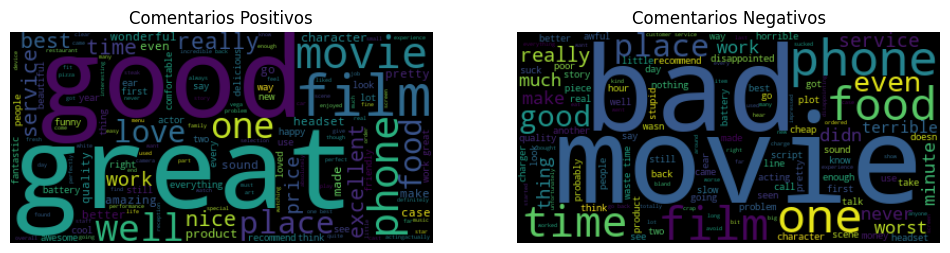

In [492]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,12))

# Nube de palabras de comentarios positivos:
wordcloudnn = WordCloud().generate(pt)
ax1.imshow(wordcloudnn, interpolation='bilinear')
ax1.axis("off")
ax1.set_title('Comentarios Positivos')

# Nube de palabras de comentarios negativos:
wordcloudnn = WordCloud().generate(nt)
ax2.imshow(wordcloudnn, interpolation='bilinear')
ax2.axis("off")
ax2.set_title('Comentarios Negativos')

plt.show()


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**


Las nubes de palabras permiten identificar visualmente los términos más frecuentes en comentarios positivos y negativos. Se observa que los comentarios positivos contienen palabras asociadas con satisfacción como “good”, “great” y “excellent”, mientras que los negativos incluyen términos como “bad”, “problem” y “waste”. Sin embargo, algunas palabras frecuentes aparecen en ambas clases, por lo que la nube debe interpretarse como una herramienta exploratoria y no como una clasificación definitiva del sentimiento.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [493]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1,stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1,stratify=y_val_and_test)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


In [494]:
print('\nTrain distribution:')
print(y_train.value_counts(normalize=True))

print('\nValidation distribution:')
print(y_val.value_counts(normalize=True))

print('\nTest distribution:')
print(y_test.value_counts(normalize=True))


Train distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [495]:
from collections import Counter

In [496]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3696

(word,frequency):
[('not', 301), ('good', 165), ('movie', 149), ('great', 148), ('phone', 141), ('film', 119), ('one', 111), ('like', 93), ('food', 93), ('time', 87)]


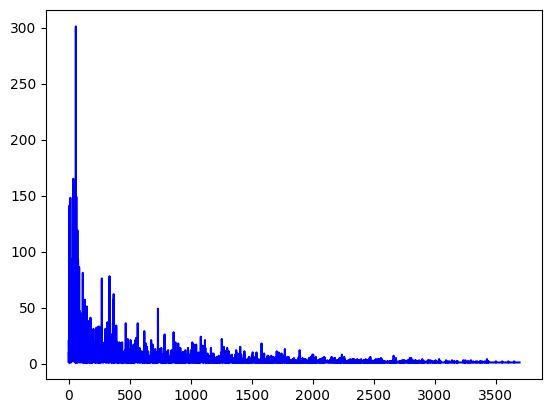

In [497]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

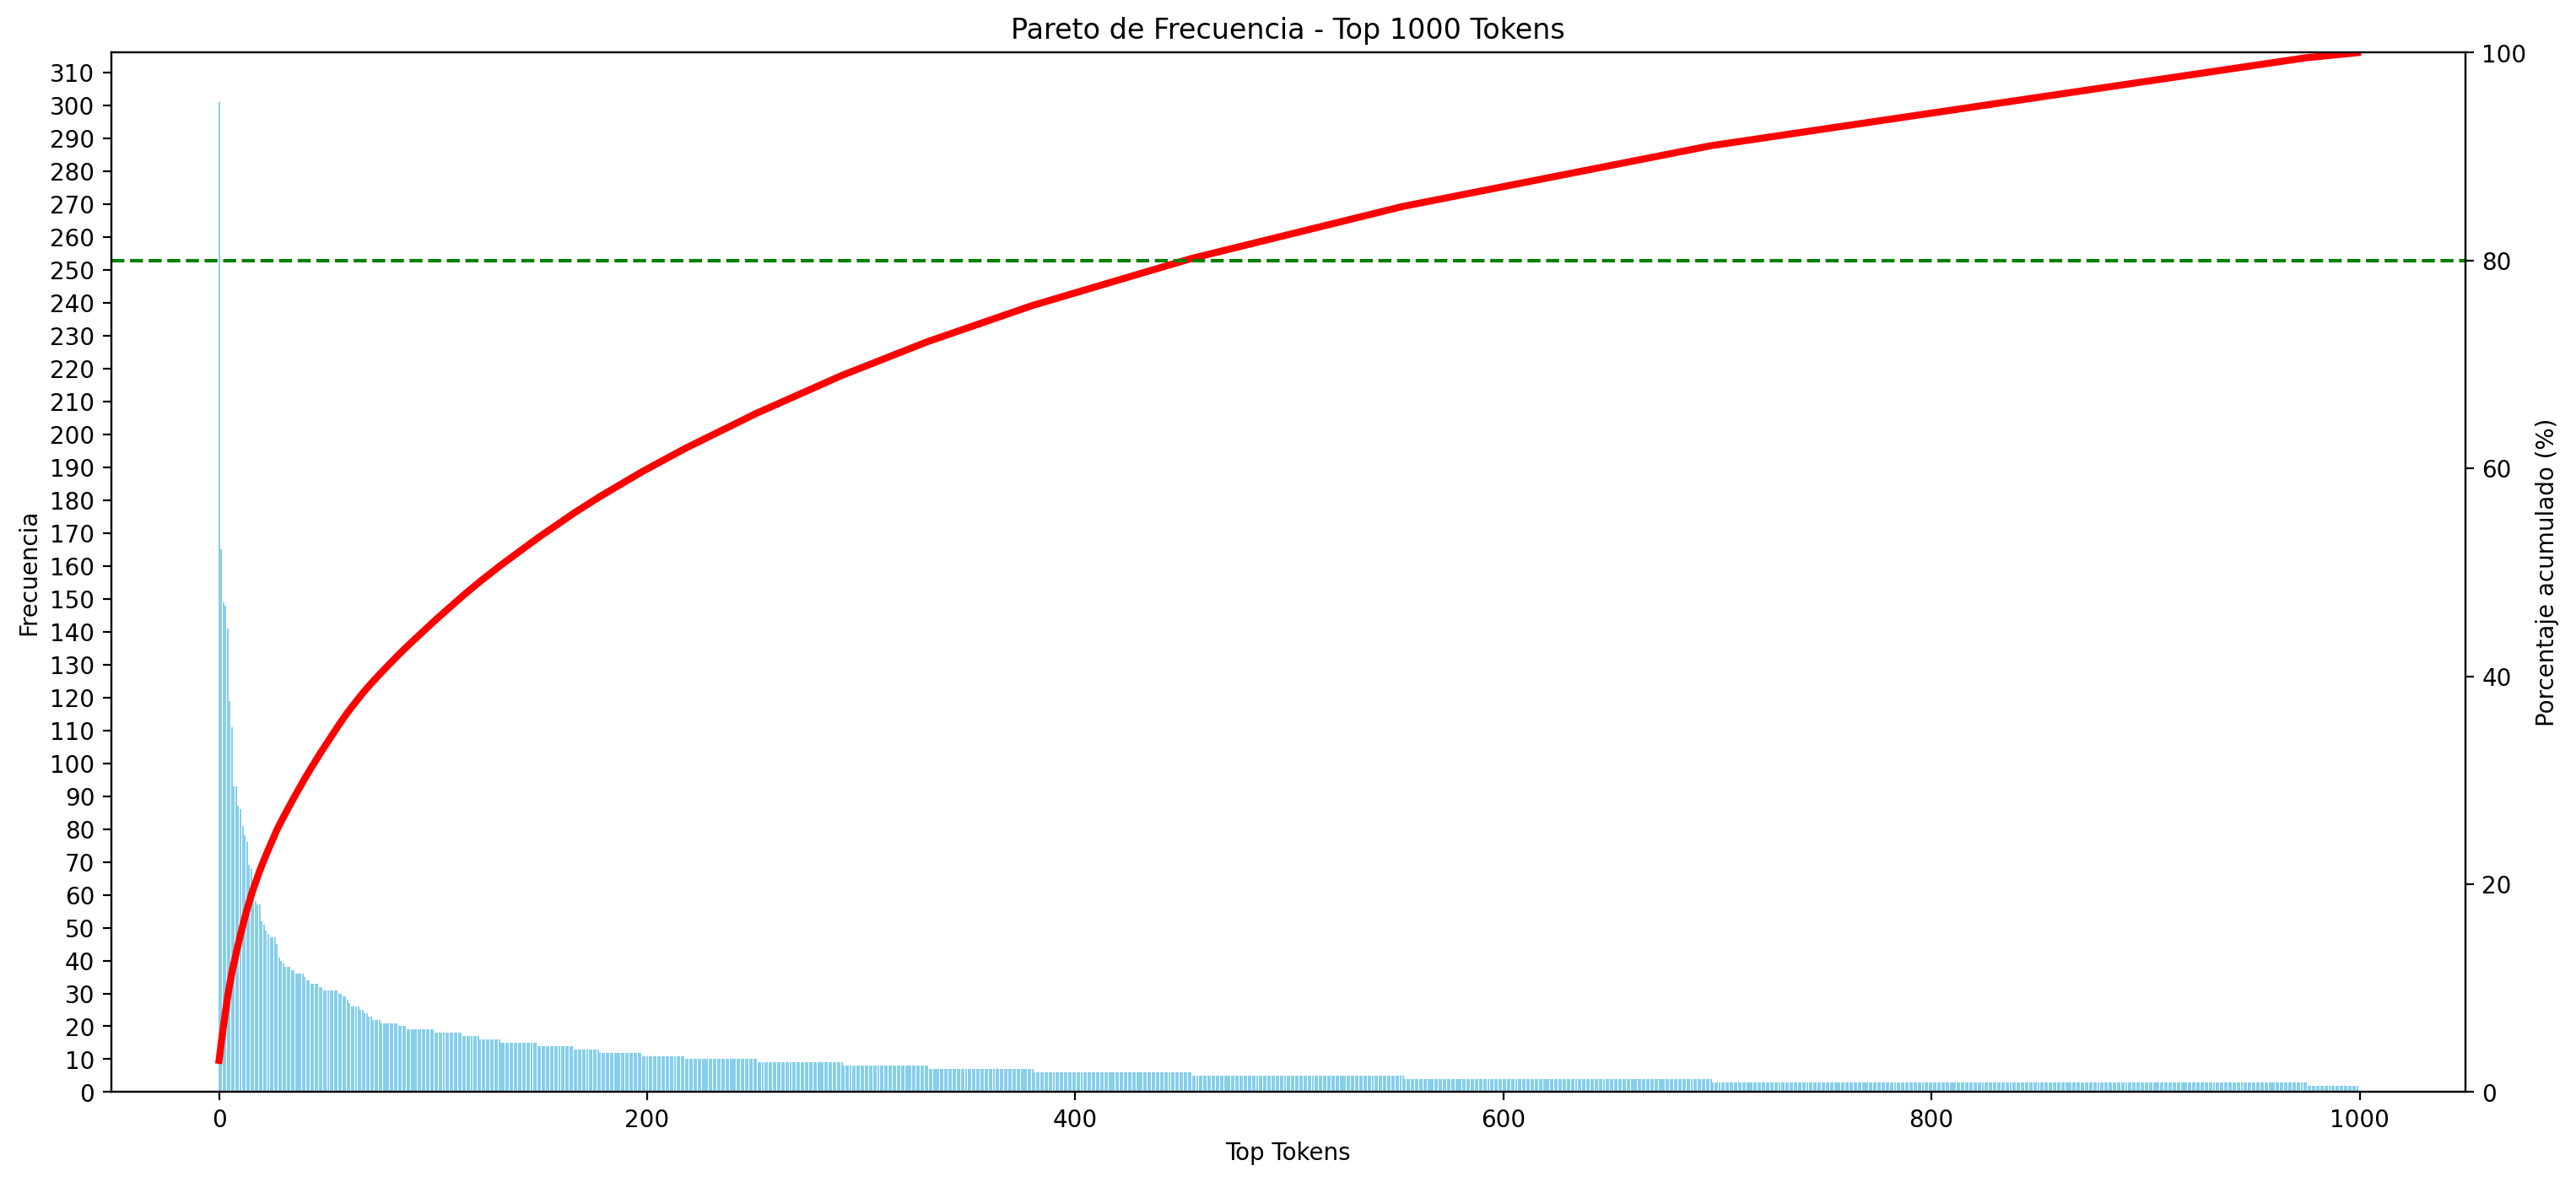

In [498]:
import numpy as np
import matplotlib.pyplot as plt

# ordenar frecuencias
freqs = sorted(midiccionario.values(), reverse=True)

# limitar a top N
top_n = 1000

freqs_top = freqs[:top_n]

# porcentaje acumulado
cumperc = np.cumsum(freqs_top) / np.sum(freqs_top) * 100

# gráfica
fig, ax1 = plt.subplots(figsize=(18,8), dpi=200)

# barras
ax1.bar(range(top_n), freqs_top, color='skyblue')

ax1.set_yticks(range(0, max(freqs)+10, 10))
ax1.set_xlabel('Top Tokens')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Pareto de Frecuencia - Top {top_n} Tokens')

# segunda escala
ax2 = ax1.twinx()

# línea acumulada
ax2.plot(range(top_n), cumperc, color='red', linewidth=3)

ax2.set_ylabel('Porcentaje acumulado (%)')
ax2.set_ylim(0, 100)

# línea 80%
ax2.axhline(80, color='green', linestyle='--')

plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [499]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

min_freq = 3

midicc = {
    word: freq
    for word, freq in midiccionario.items()
    if freq >= min_freq
}


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 3696
[('people', 20), ('couldnt', 1), ('hear', 10), ('talk', 7), ('pull', 3)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [500]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [501]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['people', 'couldnt', 'hear', 'talk', 'pull', 'earphone', 'talk', 'phone']
Después: ['people', 'couldnt', 'hear', 'talk', 'pull', 'earphone', 'talk', 'phone']
Antes: ['posted', 'detailed', 'comment', 'grey', 'black', 'phone', 'fire', 'red', 'great', 'color']
Después: ['posted', 'detailed', 'comment', 'grey', 'black', 'phone', 'fire', 'red', 'great', 'color']
Antes: ['hoping']
Después: ['hoping']


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [502]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

people couldnt hear talk pull earphone talk phone
posted detailed comment grey black phone fire red great color
hoping


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [503]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

#countvectorizer = CountVectorizer(vocabulary=mivocab, ngram_range=(1,2))
countvectorizer = CountVectorizer(min_df=3, ngram_range=(1,2))

train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:20,0:18])   # veamos las frecuencias de los primeros comentarios.

    able  absolutely  absolutely no  acted  acting  action  actor  actress  \
0      0           0              0      0       0       0      0        0   
1      0           0              0      0       0       0      0        0   
2      0           0              0      0       0       0      0        0   
3      0           0              0      0       0       0      0        0   
4      0           0              0      0       1       0      0        0   
5      0           0              0      0       0       0      0        0   
6      0           0              0      0       0       0      0        0   
7      0           0              0      0       0       0      0        0   
8      0           0              0      0       0       0      0        0   
9      0           0              0      0       0       0      0        0   
10     0           0              0      0       0       0      0        0   
11     0           0              0      0       0       0      

In [504]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 2352000
Total de valores no cero: 10229
Total de valores cero: 2341771
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.57%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.43%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [505]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

from sklearn.feature_extraction.text import TfidfVectorizer


# Generamos matrices TF-IDF usando el mismo vocabulario
#tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)
#using min_df instead of mivocab to be able to add ngram_range
tfidfvectorizer = TfidfVectorizer(min_df=3, ngram_range=(1,2))

#fit_transform(train_x_docs) aprende el peso TF-IDF con el set de entrenamiento.
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)

#transform(val_x_docs) y transform(test_x_docs) aplican la misma lógica al set de validación y prueba.
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)
#No usamos fit_transform() en validación/test para evitar data leakage.

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = tfidf_tokens)
print(df_tfidfvect.iloc[0:10,0:18])   # veamos algunos valores tf-idf de los primeros comentarios.

   able  absolutely  absolutely no  acted    acting  action  actor  actress  \
0   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
1   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
2   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
3   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
4   0.0         0.0            0.0    0.0  0.311956     0.0    0.0      0.0   
5   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
6   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
7   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
8   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   
9   0.0         0.0            0.0    0.0  0.000000     0.0    0.0      0.0   

   actually  adorable  age  ago  almost  along  already  also  although  \
0       0.0       0.0  0.0  0.0     0.0    0.0      0.0

##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [506]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [516]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
modeloLRcount = LogisticRegression(
    random_state=1,
    max_iter=1000,
    C=0.02
)

modeloLRcount.fit(train_x_count, y_train)


# Modelo Bosque Aleatorio (Random Forest):
modeloRFcount = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=1
)

modeloRFcount.fit(train_x_count, y_train)



# Modelos probabilístico Bayes Ingenuo (Naive Bayes):
modeloNBcount = MultinomialNB(
    alpha=10.0
)

modeloNBcount.fit(train_x_count, y_train)





# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))

LR: Train-accuracy: 84.14%
LR: Val-accuracy: 79%

RF: Train-accuracy: 85.90%
RF: Val-accuracy: 81.56%

NB: Train-accuracy: 86.52%
NB: Val-accuracy: 80.44%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**


None


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

##**Pregunta - 10:**

In [508]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

resultados = []

# ============================================================
# Grid Search extendido - Logistic Regression
# ============================================================
for C in [0.001, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1]:

    modelo = LogisticRegression(
        random_state=1,
        max_iter=1000,
        C=C
    )

    modelo.fit(train_x_count, y_train)

    train_acc = modelo.score(train_x_count, y_train)
    val_acc = modelo.score(val_x_count, y_val)
    test_acc = modelo.score(test_x_count, y_test)

    diff_train_val = abs(train_acc - val_acc)
    diff_val_test = abs(val_acc - test_acc)

    resultados.append([
        "LogisticRegression",
        f"C={C}",
        train_acc,
        val_acc,
        test_acc,
        diff_train_val,
        diff_val_test
    ])


# ============================================================
# Grid Search extendido - Random Forest
# ============================================================
for n_estimators in [150, 300]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 3, 4, 6]:
            for min_samples_split in [2, 5, 10]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_count, y_train)

                train_acc = modelo.score(train_x_count, y_train)
                val_acc = modelo.score(val_x_count, y_val)
                test_acc = modelo.score(test_x_count, y_test)

                diff_train_val = abs(train_acc - val_acc)
                diff_val_test = abs(val_acc - test_acc)

                resultados.append([
                    "RandomForest",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    train_acc,
                    val_acc,
                    test_acc,
                    diff_train_val,
                    diff_val_test
                ])


# ============================================================
# Grid Search extendido - Naive Bayes
# ============================================================
for alpha in [1, 2, 3, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]:

    modelo = MultinomialNB(alpha=alpha)

    modelo.fit(train_x_count, y_train)

    train_acc = modelo.score(train_x_count, y_train)
    val_acc = modelo.score(val_x_count, y_val)
    test_acc = modelo.score(test_x_count, y_test)

    diff_train_val = abs(train_acc - val_acc)
    diff_val_test = abs(val_acc - test_acc)

    resultados.append([
        "MultinomialNB",
        f"alpha={alpha}",
        train_acc,
        val_acc,
        test_acc,
        diff_train_val,
        diff_val_test
    ])


# ============================================================
# DataFrame resultados
# ============================================================
df_grid_ext = pd.DataFrame(
    resultados,
    columns=[
        "modelo",
        "params",
        "train_acc",
        "val_acc",
        "test_acc",
        "diff_train_val",
        "diff_val_test"
    ]
)

# ============================================================
# Filtrar modelos válidos
# ============================================================
df_grid_ext_ok = df_grid_ext[
    (df_grid_ext["val_acc"] > 0.79) &
    (df_grid_ext["diff_train_val"] < 0.04)
]

# ============================================================
# Mostrar mejores resultados
# ============================================================
print("Top modelos por validation accuracy:")
display(
    df_grid_ext.sort_values(
        by="val_acc",
        ascending=False
    ).head(20)
)

print("Modelos que cumplen requisitos:")
display(
    df_grid_ext_ok.sort_values(
        by="val_acc",
        ascending=False
    )
)

Top modelos por validation accuracy:


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
190,MultinomialNB,alpha=1,0.897143,0.824444,0.775556,0.072698,0.048889
40,RandomForest,"n=150, depth=12, leaf=1, split=2",0.866190,0.815556,0.777778,0.050635,0.037778
63,RandomForest,"n=150, depth=15, leaf=3, split=10",0.840952,0.815556,0.764444,0.025397,0.051111
61,RandomForest,"n=150, depth=15, leaf=3, split=2",0.840476,0.815556,0.766667,0.024921,0.048889
62,RandomForest,"n=150, depth=15, leaf=3, split=5",0.840476,0.815556,0.766667,0.024921,0.048889
191,MultinomialNB,alpha=2,0.892381,0.815556,0.777778,0.076825,0.037778
175,RandomForest,"n=300, depth=25, leaf=1, split=2",0.910476,0.815556,0.795556,0.094921,0.020000
88,RandomForest,"n=150, depth=25, leaf=2, split=2",0.859524,0.815556,0.777778,0.043968,0.037778
89,RandomForest,"n=150, depth=25, leaf=2, split=5",0.858571,0.815556,0.780000,0.043016,0.035556
90,RandomForest,"n=150, depth=25, leaf=2, split=10",0.859524,0.815556,0.782222,0.043968,0.033333


Modelos que cumplen requisitos:


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
62,RandomForest,"n=150, depth=15, leaf=3, split=5",0.840476,0.815556,0.766667,0.024921,0.048889
61,RandomForest,"n=150, depth=15, leaf=3, split=2",0.840476,0.815556,0.766667,0.024921,0.048889
63,RandomForest,"n=150, depth=15, leaf=3, split=10",0.840952,0.815556,0.764444,0.025397,0.051111
79,RandomForest,"n=150, depth=20, leaf=4, split=2",0.833333,0.808889,0.762222,0.024444,0.046667
80,RandomForest,"n=150, depth=20, leaf=4, split=5",0.833333,0.808889,0.762222,0.024444,0.046667
...,...,...,...,...,...,...,...
143,RandomForest,"n=300, depth=12, leaf=6, split=5",0.810000,0.791111,0.760000,0.018889,0.031111
159,RandomForest,"n=300, depth=15, leaf=6, split=10",0.811905,0.791111,0.751111,0.020794,0.040000
156,RandomForest,"n=300, depth=15, leaf=4, split=10",0.830476,0.791111,0.760000,0.039365,0.031111
157,RandomForest,"n=300, depth=15, leaf=6, split=2",0.811905,0.791111,0.751111,0.020794,0.040000


In [509]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

resultados_final = []

# ============================================================
# 1. Logistic Regression - Count
# ============================================================
for C in [0.05, 0.1, 0.3, 0.5, 1, 2, 3]:

    modelo = LogisticRegression(
        C=C,
        max_iter=2000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "LR Count",
        f"C={C}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# 2. Logistic Regression - TFIDF
# ============================================================
for C in [0.1, 0.3, 0.5, 1, 2, 3, 5]:

    modelo = LogisticRegression(
        C=C,
        max_iter=2000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_tfidf, y_train)

    resultados_final.append([
        "LR TFIDF",
        f"C={C}",
        modelo.score(train_x_tfidf, y_train),
        modelo.score(val_x_tfidf, y_val),
        modelo.score(test_x_tfidf, y_test)
    ])


# ============================================================
# 3. Linear SVM - Count
# ============================================================
for C in [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1]:

    modelo = LinearSVC(
        C=C,
        random_state=1,
        max_iter=3000
    )

    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "LinearSVC Count",
        f"C={C}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# 4. Linear SVM - TFIDF
# ============================================================
for C in [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1]:

    modelo = LinearSVC(
        C=C,
        random_state=1,
        max_iter=3000
    )

    modelo.fit(train_x_tfidf, y_train)

    resultados_final.append([
        "LinearSVC TFIDF",
        f"C={C}",
        modelo.score(train_x_tfidf, y_train),
        modelo.score(val_x_tfidf, y_val),
        modelo.score(test_x_tfidf, y_test)
    ])


# ============================================================
# 5. Naive Bayes - Count
# ============================================================
for alpha in [0.1, 0.3, 0.5, 1, 2, 3, 5, 10]:

    modelo = MultinomialNB(alpha=alpha)
    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "NB Count",
        f"alpha={alpha}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# 6. Random Forest - Count
# ============================================================
for n_estimators in [150, 300]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 4, 6,8]:
            for min_samples_split in [2, 5, 10,15]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_count, y_train)

                resultados_final.append([
                    "RF Count",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_count, y_train),
                    modelo.score(val_x_count, y_val),
                    modelo.score(test_x_count, y_test)
                ])


# ============================================================
# 7. Random Forest - TFIDF
# ============================================================
for n_estimators in [150, 300]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 4, 6,8]:
            for min_samples_split in [2, 5, 10,15]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_tfidf, y_train)

                resultados_final.append([
                    "RF TFIDF",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_tfidf, y_train),
                    modelo.score(val_x_tfidf, y_val),
                    modelo.score(test_x_tfidf, y_test)
                ])


# ============================================================
# Results
# ============================================================
df_final = pd.DataFrame(
    resultados_final,
    columns=["modelo", "params", "train_acc", "val_acc", "test_acc"]
)

df_final["diff_train_val"] = abs(df_final["train_acc"] - df_final["val_acc"])
df_final["diff_val_test"] = abs(df_final["val_acc"] - df_final["test_acc"])

display(df_final.sort_values(by="test_acc", ascending=False).head(30))

display(
    df_final[
        (df_final["test_acc"] > 0.79) &
        (df_final["diff_train_val"] < 0.04)
    ].sort_values(by="test_acc", ascending=False)
)

,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
25,LinearSVC TFIDF,C=0.3,0.931429,0.835556,0.808889,0.095873,0.026667
15,LinearSVC Count,C=0.03,0.905238,0.815556,0.806667,0.089683,0.008889
16,LinearSVC Count,C=0.05,0.915714,0.811111,0.804444,0.104603,0.006667
26,LinearSVC TFIDF,C=0.5,0.945714,0.811111,0.802222,0.134603,0.008889
12,LR TFIDF,C=3,0.933810,0.831111,0.800000,0.102698,0.031111
2,LR Count,C=0.3,0.905714,0.806667,0.797778,0.099048,0.008889
137,RF Count,"n=150, depth=25, leaf=1, split=5",0.902857,0.813333,0.797778,0.089524,0.015556
24,LinearSVC TFIDF,C=0.1,0.911429,0.826667,0.797778,0.084762,0.028889
10,LR TFIDF,C=1,0.913333,0.826667,0.797778,0.086667,0.028889
256,RF Count,"n=300, depth=25, leaf=1, split=2",0.910476,0.815556,0.795556,0.094921,0.020000


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test


In [515]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

resultados_final = []

# ============================================================
# 1. Logistic Regression - Count
# ============================================================
for C in [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.3]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "LR Count",
        f"C={C}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# 2. Logistic Regression - TFIDF
# ============================================================
for C in [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.3, 0.5, 1]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_tfidf, y_train)

    resultados_final.append([
        "LR TFIDF",
        f"C={C}",
        modelo.score(train_x_tfidf, y_train),
        modelo.score(val_x_tfidf, y_val),
        modelo.score(test_x_tfidf, y_test)
    ])


# ============================================================
# 3. Random Forest - Count
# ============================================================
for n_estimators in [150, 300, 500, 600]:
    for max_depth in [8, 10, 12, 15, 20, 25, 30]:
        for min_samples_leaf in [1, 2, 4, 6, 8, 10]:
            for min_samples_split in [2, 5, 10, 15, 20, 30]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_count, y_train)

                resultados_final.append([
                    "RF Count",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_count, y_train),
                    modelo.score(val_x_count, y_val),
                    modelo.score(test_x_count, y_test)
                ])


# ============================================================
# 4. Random Forest - TFIDF
# ============================================================
for n_estimators in [150, 300, 500]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 4, 6, 8]:
            for min_samples_split in [2, 5, 10, 15, 20]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_tfidf, y_train)

                resultados_final.append([
                    "RF TFIDF",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_tfidf, y_train),
                    modelo.score(val_x_tfidf, y_val),
                    modelo.score(test_x_tfidf, y_test)
                ])


# ============================================================
# 5. Naive Bayes - Count
# ============================================================
for alpha in [0.1, 0.3, 0.5, 1, 2, 3, 5, 10, 15, 20, 30, 50]:

    modelo = MultinomialNB(alpha=alpha)
    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "NB Count",
        f"alpha={alpha}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# Results
# ============================================================
df_final = pd.DataFrame(
    resultados_final,
    columns=["modelo", "params", "train_acc", "val_acc", "test_acc"]
)

df_final["diff_train_val"] = abs(df_final["train_acc"] - df_final["val_acc"])
df_final["diff_val_test"] = abs(df_final["val_acc"] - df_final["test_acc"])

display(df_final.sort_values(by="test_acc", ascending=False).head(50))

display(
    df_final[
        (df_final["test_acc"] > 0.79) &
        (df_final["diff_train_val"] < 0.04)
    ].sort_values(by="test_acc", ascending=False)
)

,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
743,RF Count,"n=500, depth=30, leaf=1, split=15",0.893333,0.822222,0.800000,0.071111,0.022222
19,LR TFIDF,C=1,0.913333,0.826667,0.797778,0.086667,0.028889
201,RF Count,"n=150, depth=25, leaf=1, split=5",0.902857,0.813333,0.797778,0.089524,0.015556
8,LR Count,C=0.3,0.905714,0.806667,0.797778,0.099048,0.008889
705,RF Count,"n=500, depth=25, leaf=1, split=5",0.904286,0.813333,0.795556,0.090952,0.017778
704,RF Count,"n=500, depth=25, leaf=1, split=2",0.921429,0.813333,0.795556,0.108095,0.017778
707,RF Count,"n=500, depth=25, leaf=1, split=15",0.890952,0.811111,0.795556,0.079841,0.015556
708,RF Count,"n=500, depth=25, leaf=1, split=20",0.882857,0.811111,0.795556,0.071746,0.015556
200,RF Count,"n=150, depth=25, leaf=1, split=2",0.910952,0.808889,0.795556,0.102063,0.013333
488,RF Count,"n=300, depth=30, leaf=1, split=2",0.920952,0.815556,0.795556,0.105397,0.020000


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test


* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [517]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.


modeloLRtfidf = LogisticRegression(
    random_state=1,
    max_iter=1000,
    C=0.02
)

modeloLRtfidf.fit(train_x_tfidf, y_train)


modeloRFtfidf = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=1
)

modeloRFtfidf.fit(train_x_tfidf, y_train)


modeloNBtfidf = MultinomialNB(
    alpha=10.0
)

modeloNBtfidf.fit(train_x_tfidf, y_train)





# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 87.05%
LR: Val-accuracy: 81%

RF: Train-accuracy: 87.67%
RF: Val-accuracy: 80.22%

NB: Train-accuracy: 88.14%
NB: Val-accuracy: 81.78%


In [511]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

resultados_tfidf = []

# Logistic Regression TF-IDF
for C in [0.001, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.3, 1.0]:

    modelo = LogisticRegression(
        random_state=1,
        max_iter=1000,
        C=C
    )

    modelo.fit(train_x_tfidf, y_train)

    train_acc = modelo.score(train_x_tfidf, y_train)
    val_acc = modelo.score(val_x_tfidf, y_val)
    test_acc = modelo.score(test_x_tfidf, y_test)

    resultados_tfidf.append([
        "LogisticRegression",
        f"C={C}",
        train_acc,
        val_acc,
        test_acc,
        abs(train_acc - val_acc),
        abs(val_acc - test_acc)
    ])


# Random Forest TF-IDF
for n_estimators in [150, 300]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 3, 4, 6]:
            for min_samples_split in [2, 5, 10]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_tfidf, y_train)

                train_acc = modelo.score(train_x_tfidf, y_train)
                val_acc = modelo.score(val_x_tfidf, y_val)
                test_acc = modelo.score(test_x_tfidf, y_test)

                resultados_tfidf.append([
                    "RandomForest",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    train_acc,
                    val_acc,
                    test_acc,
                    abs(train_acc - val_acc),
                    abs(val_acc - test_acc)
                ])


# Naive Bayes TF-IDF
for alpha in [1, 2, 3, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200]:

    modelo = MultinomialNB(alpha=alpha)

    modelo.fit(train_x_tfidf, y_train)

    train_acc = modelo.score(train_x_tfidf, y_train)
    val_acc = modelo.score(val_x_tfidf, y_val)
    test_acc = modelo.score(test_x_tfidf, y_test)

    resultados_tfidf.append([
        "MultinomialNB",
        f"alpha={alpha}",
        train_acc,
        val_acc,
        test_acc,
        abs(train_acc - val_acc),
        abs(val_acc - test_acc)
    ])


df_grid_tfidf = pd.DataFrame(
    resultados_tfidf,
    columns=[
        "modelo",
        "params",
        "train_acc",
        "val_acc",
        "test_acc",
        "diff_train_val",
        "diff_val_test"
    ]
)

df_grid_tfidf_ok = df_grid_tfidf[
    (df_grid_tfidf["val_acc"] > 0.79) &
    (df_grid_tfidf["diff_train_val"] < 0.04)
]

print("Top modelos TF-IDF por validation accuracy:")
display(df_grid_tfidf.sort_values(by="val_acc", ascending=False).head(20))

print("Modelos TF-IDF que cumplen requisitos:")
display(df_grid_tfidf_ok.sort_values(by="val_acc", ascending=False))


Top modelos TF-IDF por validation accuracy:


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
11,LogisticRegression,C=1.0,0.914286,0.824444,0.797778,0.089841,0.026667
10,LogisticRegression,C=0.3,0.892857,0.820000,0.784444,0.072857,0.035556
9,LogisticRegression,C=0.1,0.877619,0.820000,0.773333,0.057619,0.046667
196,MultinomialNB,alpha=10,0.881429,0.817778,0.782222,0.063651,0.035556
177,RandomForest,"n=300, depth=25, leaf=1, split=2",0.925714,0.817778,0.777778,0.107937,0.040000
123,RandomForest,"n=300, depth=10, leaf=3, split=2",0.845714,0.815556,0.768889,0.030159,0.046667
124,RandomForest,"n=300, depth=10, leaf=3, split=5",0.845714,0.815556,0.768889,0.030159,0.046667
178,RandomForest,"n=300, depth=25, leaf=1, split=5",0.913810,0.815556,0.775556,0.098254,0.040000
117,RandomForest,"n=300, depth=10, leaf=1, split=2",0.869048,0.815556,0.773333,0.053492,0.042222
125,RandomForest,"n=300, depth=10, leaf=3, split=10",0.844286,0.813333,0.768889,0.030952,0.044444


Modelos TF-IDF que cumplen requisitos:


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
124,RandomForest,"n=300, depth=10, leaf=3, split=5",0.845714,0.815556,0.768889,0.030159,0.046667
123,RandomForest,"n=300, depth=10, leaf=3, split=2",0.845714,0.815556,0.768889,0.030159,0.046667
125,RandomForest,"n=300, depth=10, leaf=3, split=10",0.844286,0.813333,0.768889,0.030952,0.044444
122,RandomForest,"n=300, depth=10, leaf=2, split=10",0.850952,0.813333,0.777778,0.037619,0.035556
120,RandomForest,"n=300, depth=10, leaf=2, split=2",0.849524,0.813333,0.777778,0.036190,0.035556
128,RandomForest,"n=300, depth=10, leaf=4, split=10",0.842857,0.813333,0.764444,0.029524,0.048889
126,RandomForest,"n=300, depth=10, leaf=4, split=2",0.843810,0.813333,0.764444,0.030476,0.048889
127,RandomForest,"n=300, depth=10, leaf=4, split=5",0.843810,0.813333,0.764444,0.030476,0.048889
121,RandomForest,"n=300, depth=10, leaf=2, split=5",0.849048,0.811111,0.777778,0.037937,0.033333
131,RandomForest,"n=300, depth=10, leaf=6, split=10",0.829048,0.806667,0.753333,0.022381,0.053333


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**


None


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

In [520]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT :

from sklearn.metrics import confusion_matrix

# Mejor modelo encontrado:
mejor_modelo = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=1,
    n_jobs=-1
)

# Entrenamos nuevamente el mejor modelo usando CountVectorizer
mejor_modelo.fit(train_x_count, y_train)

# Conjunto de prueba asociado al mejor modelo:
test_x_asociada = test_x_count

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 79.11%

Matriz de confusión con el mejor modelo:
[[191  34]
 [ 60 165]]

Matriz de confusión con el mejor modelo en proporciones:
[[0.42444444 0.07555556]
 [0.13333333 0.36666667]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**


## Conclusiones sobre los retos de la actividad

Uno de los principales retos de esta actividad fue lograr simultáneamente dos objetivos que normalmente entran en conflicto en problemas de Machine Learning y NLP:

* obtener un accuracy alto en el conjunto de prueba,
* y mantener una diferencia pequeña entre entrenamiento y validación para evitar sobreentrenamiento.

Durante el desarrollo se observó que varios modelos alcanzaban accuracies superiores al 80% en validación y prueba, pero presentaban diferencias relativamente altas entre entrenamiento y validación, indicando cierto nivel de memorización del conjunto de entrenamiento.

Para intentar reducir este problema se realizaron múltiples experimentos y ajustes, entre ellos:

* uso de `stratify` durante la división Train/Validation/Test,
* eliminación de palabras poco frecuentes mediante `min_df`,
* lematización,
* incorporación de bigramas (`ngram_range=(1,2)`),
* ajuste de hiperparámetros de regularización,
* y comparación entre representaciones CountVectorizer y TF-IDF.

Uno de los aprendizajes importantes fue observar cómo pequeños cambios en el preprocesamiento podían impactar significativamente el balance entre generalización y sobreentrenamiento. Por ejemplo:

* aumentar demasiado `min_df` reducía el sobreentrenamiento, pero también eliminaba información útil y disminuía el accuracy en prueba;
* mientras que configuraciones más flexibles mejoraban el accuracy, pero incrementaban la diferencia entre entrenamiento y validación.

También se identificó que Random Forest con matrices de conteo (CountVectorizer) ofreció el mejor balance general para este conjunto de datos, superando en varios casos a TF-IDF. Esto sugiere que en este problema las frecuencias naturales de las palabras conservaron información importante para la clasificación.

En general, la actividad permitió entender de manera práctica la dificultad real de optimizar modelos NLP, especialmente cuando se busca no solamente maximizar accuracy, sino también controlar el sobreentrenamiento y mantener capacidad de generalización sobre datos no vistos.



###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**